# Meltome-HumanCell Results Visualization

This notebook visualizes the ProtT5 aggregation sweep on the Meltome-HumanCell dataset. The x-axis is the `dim` setting for `cov` and `hybrid` (`8, 16, 24, 32, 48`), and horizontal reference lines show the `mean` and `LA` results.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.28,
    "grid.linestyle": "--",
})

## Data

`cov - 8` means `method=cov, dim=8`; its Spearman R is `0.709`, not `80.709`.

In [21]:
results = pd.DataFrame([
    {"method": "cov", "dim": 8, "spearman_r": 0.709, "mse": 2560.643, "mae": 50.442},
    {"method": "cov", "dim": 16, "spearman_r": 0.715, "mse": 2628.352, "mae": 51.094},
    {"method": "cov", "dim": 24, "spearman_r": 0.713, "mse": 2613.515, "mae": 50.949},
    {"method": "cov", "dim": 32, "spearman_r": 0.714, "mse": 2592.420 , "mae": 50.755},
    {"method": "cov", "dim": 48, "spearman_r": 0.717, "mse": 2639.928, "mae": 51.205},
    {"method": "hybrid", "dim": 8, "spearman_r": 0.720, "mse": 2652.930, "mae": 51.350},
    {"method": "hybrid", "dim": 16, "spearman_r": 0.716, "mse": 2572.062, "mae": 50.558},
    {"method": "hybrid", "dim": 24, "spearman_r": 0.717, "mse": 2659.266, "mae": 51.413},
    {"method": "hybrid", "dim": 32, "spearman_r": 0.716, "mse": 2661.894, "mae": 51.429},
    {"method": "hybrid", "dim": 48, "spearman_r": 0.719, "mse": 2659.422, "mae": 51.397},
])

baselines = pd.DataFrame([
    {"method": "LA", "spearman_r": 0.718, "mse": 2273.451, "mae": 47.512},
    {"method": "mean", "spearman_r": 0.709, "mse": 2597.901, "mae": 50.810},
])

display(results.pivot(index="dim", columns="method", values=["spearman_r", "mse", "mae"]))
display(baselines)

spearman_r              mse               mae        
method        cov hybrid       cov    hybrid     cov  hybrid
dim                                                         
8           0.709  0.720  2560.643  2652.930  50.442  51.350
16          0.715  0.716  2628.352  2572.062  51.094  50.558
24          0.713  0.717  2613.515  2659.266  50.949  51.413
32          0.714  0.716  2592.420  2661.894  50.755  51.429
48          0.717  0.719  2639.928  2659.422  51.205  51.397

,method,spearman_r,mse,mae
0,LA,0.718,2273.451,47.512
1,mean,0.709,2597.901,50.810


## Spearman R Sweep

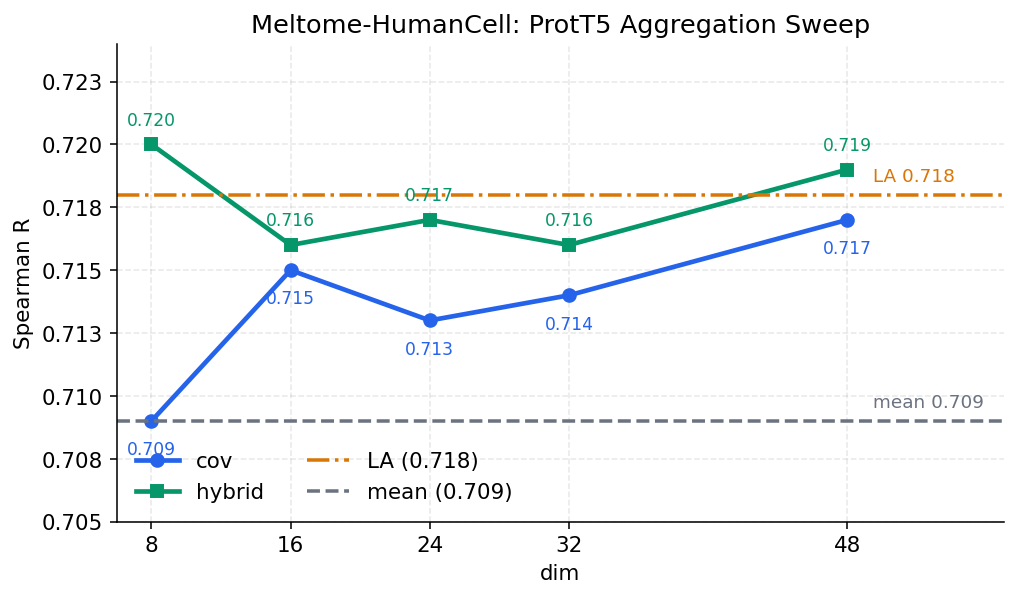

In [22]:
metric = "spearman_r"
metric_label = "Spearman R"
dims = [8, 16, 24, 32, 48]

series_styles = {
    "cov": {"color": "#2563eb", "marker": "o"},
    "hybrid": {"color": "#059669", "marker": "s"},
}
point_label_offsets = {
    "cov": {"xytext": (0, -10), "va": "top"},
    "hybrid": {"xytext": (0, 8), "va": "bottom"},
}
baseline_styles = {
    "mean": {"color": "#6b7280", "linestyle": "--"},
    "LA": {"color": "#d97706", "linestyle": "-."},
}

fig, ax = plt.subplots(figsize=(7.4, 4.4))

for method in ["cov", "hybrid"]:
    subset = results[results["method"] == method].sort_values("dim")
    ax.plot(
        subset["dim"],
        subset[metric],
        label=method,
        linewidth=2.4,
        markersize=6.5,
        **series_styles[method],
    )
    label_offset = point_label_offsets[method]
    for _, point in subset.iterrows():
        ax.annotate(
            f'{point[metric]:.3f}',
            xy=(point["dim"], point[metric]),
            xytext=label_offset["xytext"],
            textcoords="offset points",
            ha="center",
            va=label_offset["va"],
            fontsize=8.8,
            color=series_styles[method]["color"],
        )

for _, row in baselines.iterrows():
    style = baseline_styles[row["method"]]
    ax.axhline(
        y=row[metric],
        linewidth=1.8,
        label=f'{row["method"]} ({row[metric]:.3f})',
        **style,
    )
    ax.annotate(
        f'{row["method"]} {row[metric]:.3f}',
        xy=(max(dims) + 1.5, row[metric]),
        xytext=(0, 5),
        textcoords="offset points",
        va="bottom",
        ha="left",
        fontsize=9.5,
        color=style["color"],
    )

all_values = pd.concat([results[metric], baselines[metric]], ignore_index=True)
padding = max((all_values.max() - all_values.min()) * 0.18, 0.004)

ax.set_title("Meltome-HumanCell: ProtT5 Aggregation Sweep")
ax.set_xlabel("dim")
ax.set_ylabel(metric_label)
ax.set_xticks(dims)
ax.set_xlim(min(dims) - 2, max(dims) + 9)
ax.set_ylim(all_values.min() - padding, all_values.max() + padding)
ax.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))
ax.legend(frameon=False, ncols=2, loc="lower left")

fig.tight_layout()
plt.show()

Uncomment the next cell if you want to save the figure.

In [23]:
# fig.savefig("meltome_humancell_spearman_r.png", bbox_inches="tight")

## Mixed Split Data

`cov - 8` means `method=cov, dim=8`; its Spearman R is `0.710`.

In [24]:
mixed_results = pd.DataFrame([
    {"method": "cov", "dim": 8, "spearman_r": 0.710, "mse": 2167.547, "mae": 46.161},
    {"method": "cov", "dim": 16, "spearman_r": 0.727, "mse": 2002.299, "mae": 44.372},
    {"method": "cov", "dim": 24, "spearman_r": 0.721, "mse": 2167.547, "mae": 46.161},
    {"method": "cov", "dim": 32, "spearman_r": 0.721, "mse": 2300.036, "mae": 47.586},
    {"method": "cov", "dim": 48, "spearman_r": 0.734, "mse": 2573.899, "mae": 50.215},
    {"method": "hybrid", "dim": 8, "spearman_r": 0.726, "mse": 1917.228, "mae": 43.390},
    {"method": "hybrid", "dim": 16, "spearman_r": 0.727, "mse": 2084.764, "mae": 45.284},
    {"method": "hybrid", "dim": 24, "spearman_r": 0.725, "mse": 2391.825, "mae": 48.561},
    {"method": "hybrid", "dim": 32, "spearman_r": 0.730, "mse": 2452.073, "mae": 49.171},
    {"method": "hybrid", "dim": 48, "spearman_r": 0.730, "mse": 2583.628, "mae": 50.391},
])

mixed_baselines = pd.DataFrame([
    {"method": "LA", "spearman_r": 0.696, "mse": 2722.080, "mae": 51.115},
    {"method": "mean", "spearman_r": 0.718, "mse": 1844.392, "mae": 42.530},
])

display(mixed_results.pivot(index="dim", columns="method", values=["spearman_r", "mse", "mae"]))
display(mixed_baselines)

spearman_r              mse               mae        
method        cov hybrid       cov    hybrid     cov  hybrid
dim                                                         
8           0.710  0.726  2167.547  1917.228  46.161  43.390
16          0.727  0.727  2002.299  2084.764  44.372  45.284
24          0.721  0.725  2167.547  2391.825  46.161  48.561
32          0.721  0.730  2300.036  2452.073  47.586  49.171
48          0.734  0.730  2573.899  2583.628  50.215  50.391

,method,spearman_r,mse,mae
0,LA,0.696,2722.080,51.115
1,mean,0.718,1844.392,42.530


## Mixed Split Spearman R Sweep

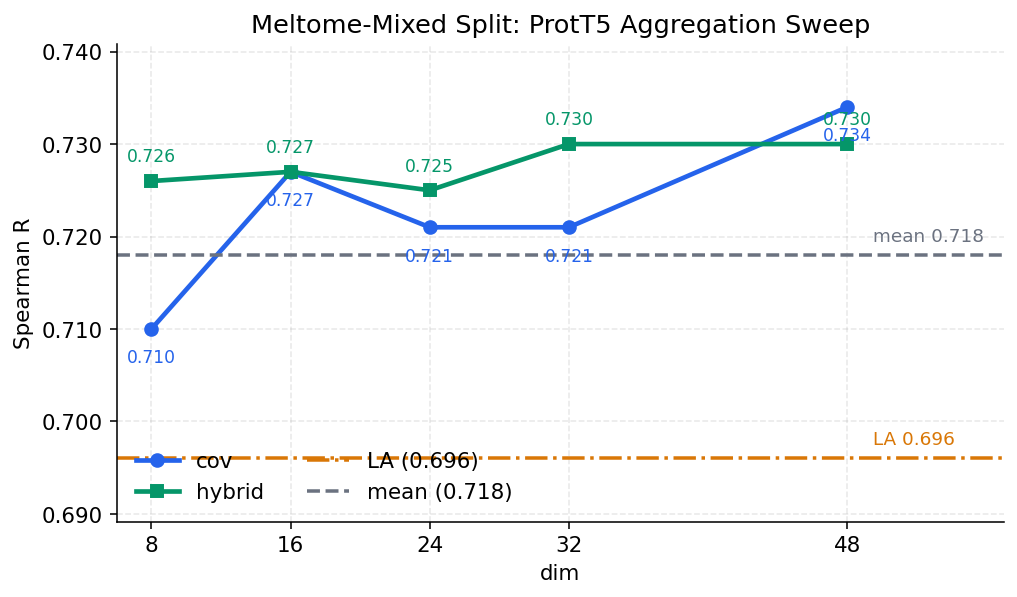

In [25]:
metric = "spearman_r"
metric_label = "Spearman R"
dims = [8, 16, 24, 32, 48]

fig, ax = plt.subplots(figsize=(7.4, 4.4))

for method in ["cov", "hybrid"]:
    subset = mixed_results[mixed_results["method"] == method].sort_values("dim")
    ax.plot(
        subset["dim"],
        subset[metric],
        label=method,
        linewidth=2.4,
        markersize=6.5,
        **series_styles[method],
    )
    label_offset = point_label_offsets[method]
    for _, point in subset.iterrows():
        ax.annotate(
            f'{point[metric]:.3f}',
            xy=(point["dim"], point[metric]),
            xytext=label_offset["xytext"],
            textcoords="offset points",
            ha="center",
            va=label_offset["va"],
            fontsize=8.8,
            color=series_styles[method]["color"],
        )

for _, row in mixed_baselines.iterrows():
    style = baseline_styles[row["method"]]
    ax.axhline(
        y=row[metric],
        linewidth=1.8,
        label=f'{row["method"]} ({row[metric]:.3f})',
        **style,
    )
    ax.annotate(
        f'{row["method"]} {row[metric]:.3f}',
        xy=(max(dims) + 1.5, row[metric]),
        xytext=(0, 5),
        textcoords="offset points",
        va="bottom",
        ha="left",
        fontsize=9.5,
        color=style["color"],
    )

all_values = pd.concat([mixed_results[metric], mixed_baselines[metric]], ignore_index=True)
padding = max((all_values.max() - all_values.min()) * 0.18, 0.004)

ax.set_title("Meltome-Mixed Split: ProtT5 Aggregation Sweep")
ax.set_xlabel("dim")
ax.set_ylabel(metric_label)
ax.set_xticks(dims)
ax.set_xlim(min(dims) - 2, max(dims) + 9)
ax.set_ylim(all_values.min() - padding, all_values.max() + padding)
ax.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))
ax.legend(frameon=False, ncols=2, loc="lower left")

fig.tight_layout()
plt.show()

Uncomment the next cell if you want to save the mixed split figure.

In [26]:
# fig.savefig("meltome_humancell_mixed_split_spearman_r.png", bbox_inches="tight")